# Week 8 — Scaling laws, training recipes, and test-time compute

Train small transformers of increasing size →
verify power-law scaling of loss vs parameters → experiment with learning
rate schedules → compare modern architecture choices → explore test-time
compute scaling (best-of-N, chain-of-thought).


Weeks 6–7 examined transformer internals and efficiency. This week steps
back to the big picture: **where should you spend compute?**

Two axes of scaling:

1. **Training-time scaling** (Parts 1–3): bigger models + more data →
   lower loss, following predictable power laws. Training recipes
   (warmup, LR schedule) determine whether you efficiently convert compute
   into performance.

2. **Test-time scaling** (Part 4): instead of training a bigger model,
   spend more compute *at inference* — generate multiple answers, let the
   model "think" longer. This is the paradigm behind o1, DeepSeek-R1, and
   the shift toward inference-time reasoning.



In [ ]:
def train_lm(model, train_data, val_data, steps=2000, lr=3e-4,
             batch_size=32, scheduler_type='cosine_warmup', warmup_frac=0.1,
             verbose=True):
    '''Train a language model. Returns train losses and val losses.'''
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # TODO: Implement the Learning rate scheduler logic
    # 1. Linear warmup for the first warmup_frac * steps
    # 2. Cosine decay (or constant) for the remainder
    scheduler = None

    n = train_data.shape[0]
    train_losses, val_losses, lrs = [], [], []

    model.train()
    for step in range(1, steps + 1):
        # TODO: Implement the training step
        # 1. Sample a random batch from train_data
        # 2. Define inputs (all but last token) and targets (all but first)
        # 3. Forward pass, CrossEntropy loss, Backward pass, and Step
        # 4. Don't forget Gradient Clipping and scheduler.step()

        if verbose and (step % (steps // 5) == 0 or step == 1):
            val_loss = evaluate_lm(model, val_data, batch_size)
            val_losses.append((step, val_loss))
            print(f"  step {step:5d}: val = {val_loss:.4f}")

    return train_losses, val_losses, lrs

@torch.no_grad()
def evaluate_lm(model, data, batch_size=32, max_batches=20):
    '''Evaluate loss on validation data.'''
    model.eval()
    # TODO: Implement evaluation loop over max_batches
    return 0.0

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
from datasets import load_dataset
from transformers import GPT2Tokenizer

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Data — WikiText-2

A standard language modeling benchmark (~2M tokens of Wikipedia text).
We tokenize with GPT-2's tokenizer and prepare fixed-length sequences
for training.

In [ ]:
from datasets import load_dataset
from transformers import GPT2Tokenizer
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

train_text = "\n".join([t for t in dataset["train"]["text"] if len(t.strip()) > 0])
val_text = "\n".join([t for t in dataset["validation"]["text"] if len(t.strip()) > 0])

train_tokens = tokenizer.encode(train_text)
val_tokens = tokenizer.encode(val_text)

print(f"Train tokens: {len(train_tokens):,}")
print(f"Val tokens:   {len(val_tokens):,}")

SEQ_LEN = 128

def make_sequences(tokens, seq_len):
    n = len(tokens) // seq_len * seq_len
    tokens = tokens[:n]
    return torch.tensor(tokens, dtype=torch.long).reshape(-1, seq_len)

train_data = make_sequences(train_tokens, SEQ_LEN).to(device)
val_data = make_sequences(val_tokens, SEQ_LEN).to(device)

print(f"Train sequences: {train_data.shape}")
print(f"Val sequences:   {val_data.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


Train tokens: 2,391,884
Val tokens:   247,289
Train sequences: torch.Size([18686, 128])
Val sequences:   torch.Size([1931, 128])


## Model — configurable causal transformer

A minimal GPT-style transformer where we can vary the size (depth, width,
heads) to study scaling behavior.

In [ ]:
class CausalTransformer(nn.Module):
    '''Minimal GPT-style causal language model.'''
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 d_ff=None, max_len=512, dropout=0.0,
                 norm_type='layernorm', ffn_act='gelu'):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model

        self.d_model = d_model
        self.tok_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout,
                             norm_type=norm_type, ffn_act=ffn_act)
            for _ in range(n_layers)
        ])

        if norm_type == 'rmsnorm':
            self.ln_f = RMSNorm(d_model)
        else:
            self.ln_f = nn.LayerNorm(d_model)

        self.head = nn.Linear(d_model, vocab_size, bias=False)
        # Weight tying
        self.head.weight = self.tok_embed.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)

    def forward(self, idx):
        # TODO: Implement the forward pass
        # 1. Get token and position embeddings
        # 2. Apply dropout to the sum
        # 3. Create a causal mask (lower triangular)
        # 4. Pass through transformer blocks
        # 5. Apply final layer norm and linear head
        pass

    def count_params(self):
        return sum(p.numel() for p in self.parameters()) - self.head.weight.numel()


class RMSNorm(nn.Module):
    '''Root Mean Square Layer Normalization.'''
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        # TODO: Initialize the gain parameter (gamma)
        pass

    def forward(self, x):
        # TODO: Implement the RMSNorm formula
        # RMS(x) = x / sqrt(mean(x^2) + eps) * weight
        pass


class SwiGLU(nn.Module):
    '''SwiGLU activation for FFN (Shazeer, 2020).'''
    def __init__(self, d_model, d_ff):
        super().__init__()
        # TODO: Define the three linear layers (w1, w2, w3)
        pass

    def forward(self, x):
        # TODO: Implement SwiGLU: W2(SiLU(W1(x)) * W3(x))
        pass


class TransformerBlock(nn.Module):
    '''Pre-norm transformer block with configurable norm and FFN.'''
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0,
                 norm_type='layernorm', ffn_act='gelu'):
        super().__init__()
        # TODO: Initialize layer norms (ln1, ln2), MultiheadAttention, and FFN
        # Handle different norm_types and ffn_acts (SwiGLU vs GELU)
        pass

    def forward(self, x, mask=None):
        # TODO: Implement pre-norm architecture
        # x = x + Attention(Norm(x))
        # x = x + FFN(Norm(x))
        pass

In [ ]:
# --- Training and evaluation utilities --------------------------------------
def train_lm(model, train_data, val_data, steps=2000, lr=3e-4,
             batch_size=32, scheduler_type='cosine_warmup', warmup_frac=0.1,
             verbose=True):
    '''Train a language model. Returns train losses and val losses.'''
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning rate scheduler
    warmup_steps = int(steps * warmup_frac)
    if scheduler_type == 'cosine_warmup':
        def lr_lambda(step):
            if step < warmup_steps:
                return step / max(warmup_steps, 1)
            progress = (step - warmup_steps) / max(steps - warmup_steps, 1)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    elif scheduler_type == 'constant':
        scheduler = None
    elif scheduler_type == 'warmup_only':
        def lr_lambda(step):
            if step < warmup_steps:
                return step / max(warmup_steps, 1)
            return 1.0
        scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    else:
        scheduler = None

    n = train_data.shape[0]
    train_losses = []
    val_losses = []
    lrs = []

    model.train()
    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), device=device)
        batch = train_data[idx]         # (batch, seq_len)
        inputs = batch[:, :-1]          # (batch, seq_len-1)
        targets = batch[:, 1:]          # (batch, seq_len-1)

        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                               targets.reshape(-1))
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if scheduler:
            scheduler.step()

        train_losses.append(loss.item())
        lrs.append(opt.param_groups[0]['lr'])

        if step % (steps // 5) == 0 or step == 1:
            val_loss = evaluate_lm(model, val_data, batch_size)
            val_losses.append((step, val_loss))
            if verbose:
                print(f"  step {step:5d}: train = {loss.item():.4f}, "
                      f"val = {val_loss:.4f}, lr = {lrs[-1]:.2e}")

    model.eval()
    return train_losses, val_losses, lrs


@torch.no_grad()
def evaluate_lm(model, data, batch_size=32, max_batches=20):
    '''Evaluate perplexity on validation data.'''
    model.eval()
    total_loss = 0
    n_batches = min(data.shape[0] // batch_size, max_batches)

    for i in range(n_batches):
        batch = data[i*batch_size:(i+1)*batch_size]
        inputs = batch[:, :-1]
        targets = batch[:, 1:]
        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                               targets.reshape(-1))
        total_loss += loss.item()

    model.train()
    return total_loss / n_batches

## Part 1 — Training scaling laws: loss vs model size

The central empirical finding of modern deep learning: for a fixed amount
of training data, **validation loss decreases as a power law with model
size**:

$$
L(N) = \alpha \cdot N^{-\beta} + L_\infty
$$

where $N$ is the parameter count, $\beta \approx 0.07$ (Kaplan et al.,
2020), and $L_\infty$ is the irreducible loss (entropy of the data).

We verify this by training four transformers of increasing size on
WikiText-2 and plotting loss vs parameters on a log-log scale. If the
power law holds, we should see a straight line.

In [ ]:
# --- Define model configurations of increasing size -------------------------
configs = [
    {'name': 'Tiny',   'd_model': 64,  'n_heads': 4, 'n_layers': 2, 'd_ff': 256},
    {'name': 'Small',  'd_model': 128, 'n_heads': 4, 'n_layers': 4, 'd_ff': 512},
    {'name': 'Medium', 'd_model': 256, 'n_heads': 8, 'n_layers': 6, 'd_ff': 1024},
    #{'name': 'Large',  'd_model': 384, 'n_heads': 8, 'n_layers': 8, 'd_ff': 1536},
]

scaling_results = []

for cfg in configs:
    torch.manual_seed(42)
    model = CausalTransformer(
        vocab_size=tokenizer.vocab_size,
        d_model=cfg['d_model'], n_heads=cfg['n_heads'],
        n_layers=cfg['n_layers'], d_ff=cfg['d_ff'],
        max_len=SEQ_LEN
    ).to(device)

    n_params = model.count_params()
    print(f"\n--- {cfg['name']} (d={cfg['d_model']}, L={cfg['n_layers']}, "
          f"params={n_params:,}) ---")

    train_losses, val_losses, _ = train_lm(
        model, train_data, val_data, steps=3000, lr=3e-4, batch_size=32
    )

    final_val = val_losses[-1][1]
    scaling_results.append({
        'name': cfg['name'],
        'params': n_params,
        'val_loss': final_val,
        'train_losses': train_losses,
        'val_losses': val_losses,
    })

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


--- Tiny (d=64, L=2, params=108,288) ---
  step     1: train = 10.8306, val = 10.8293, lr = 1.00e-06
  step   600: train = 6.9132, val = 7.0462, lr = 2.91e-04
  step  1200: train = 6.3923, val = 6.4662, lr = 2.25e-04
  step  1800: train = 6.1530, val = 6.2766, lr = 1.24e-04
  step  2400: train = 6.0517, val = 6.2089, lr = 3.51e-05
  step  3000: train = 6.0216, val = 6.1973, lr = 0.00e+00

--- Small (d=128, L=4, params=809,728) ---
  step     1: train = 10.8333, val = 10.8289, lr = 1.00e-06
  step   600: train = 6.3412, val = 6.5244, lr = 2.91e-04
  step  1200: train = 5.9424, val = 6.0635, lr = 2.25e-04
  step  1800: train = 5.5711, val = 5.8680, lr = 1.24e-04
  step  2400: train = 5.5076, val = 5.7960, lr = 3.51e-05
  step  3000: train = 5.4580, val = 5.7805, lr = 0.00e+00

--- Medium (d=256, L=6, params=4,771,840) ---
  step     1: train = 10.8805, val = 10.8810, lr = 1.00e-06
  step   600: train = 5.8945, val = 6.1577, lr = 2.91e-04
  step  1200: train = 5.4844, val = 5.7381, lr = 

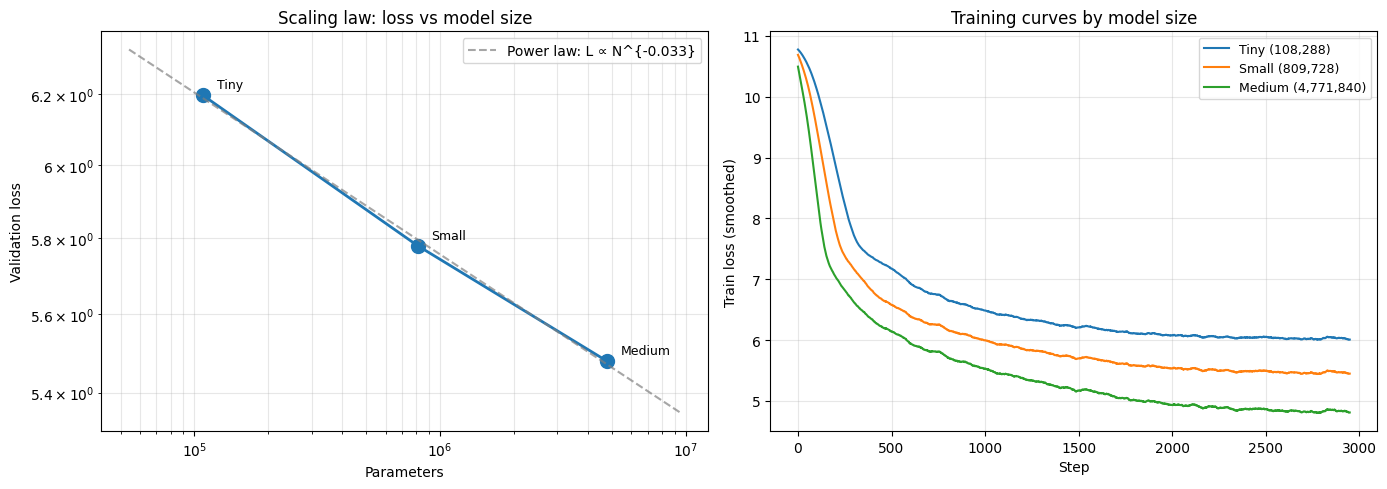


Fitted power law: L ∝ N^{-0.033}
  (Kaplan et al. found β ≈ -0.076 on larger-scale experiments)


In [ ]:
# --- Plot: loss vs parameters (log-log) -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scaling law (log-log)
ax = axes[0]
params = [r['params'] for r in scaling_results]
val_losses = [r['val_loss'] for r in scaling_results]

ax.loglog(params, val_losses, 'o-', markersize=10, color='tab:blue', linewidth=2)
for r in scaling_results:
    ax.annotate(r['name'], (r['params'], r['val_loss']),
                textcoords='offset points', xytext=(10, 5), fontsize=9)

# Fit power law: log(L) = -beta * log(N) + log(alpha)
log_params = np.log(params)
log_losses = np.log(val_losses)
beta, log_alpha = np.polyfit(log_params, log_losses, 1)
alpha = np.exp(log_alpha)

x_fit = np.logspace(np.log10(min(params)*0.5), np.log10(max(params)*2), 100)
y_fit = alpha * x_fit ** beta
ax.loglog(x_fit, y_fit, '--', color='gray', alpha=0.7,
          label=f'Power law: L ∝ N^{{{beta:.3f}}}')

ax.set_xlabel('Parameters'); ax.set_ylabel('Validation loss')
ax.set_title('Scaling law: loss vs model size')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

# Right: training curves
ax = axes[1]
window = 50
for r in scaling_results:
    smoothed = np.convolve(r['train_losses'], np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=f'{r["name"]} ({r["params"]:,})', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Train loss (smoothed)')
ax.set_title('Training curves by model size')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFitted power law: L ∝ N^{{{beta:.3f}}}")
print(f"  (Kaplan et al. found β ≈ -0.076 on larger-scale experiments)")


### The power law holds (approximately)

Even on WikiText-2 with small models (200k–10M parameters), validation
loss follows a power law in model size. The exponent $\beta$ may differ
from the large-scale value (-0.076) because we're in a different regime,
but the log-log linearity is visible.

### What the scaling law means

**Predictability**: if you know the loss at two model sizes, you can
extrapolate to predict the loss at a larger size without training it.
This is how labs decide whether to invest in a $10M training run.

### Chinchilla (Hoffmann et al., 2022)

The scaling law above fixes the data and varies the model. Chinchilla
showed that you should **scale model and data together**: given compute
budget $C$, the optimal allocation is $N \propto \sqrt{C}$ and
$D \propto \sqrt{C}$. The previous wisdom (Kaplan) suggested scaling the
model faster than the data.

**Practical consequence**: LLaMA-7B was trained on 1T tokens — far more
than Chinchilla-optimal — because a smaller model trained longer is
cheaper to *serve*. Chinchilla optimizes training cost; production
optimizes total cost (training + inference).

## Part 2 — Training recipes: learning rate schedules

The same model can converge to very different loss values depending on
the learning rate schedule. The standard recipe for transformers:

1. **Warmup**: start from LR ≈ 0, linearly ramp to target LR over ~10%
   of training. This navigates the high-curvature early phase (Week 5:
   the Hessian spike at initialization).

2. **Cosine decay**: after warmup, decay the LR following a cosine
   curve to near zero. This allows fine-grained optimization in the later
   stages.

We compare three schedules: constant LR, warmup only, and warmup +
cosine decay.

In [ ]:
# --- Train the same model with different LR schedules -----------------------
schedule_configs = [
    ('Constant LR',         'constant'),
    ('Warmup only',         'warmup_only'),
    ('Warmup + cosine',     'cosine_warmup'),
]

schedule_results = []

for sched_name, sched_type in schedule_configs:
    torch.manual_seed(42)
    model = CausalTransformer(
        vocab_size=tokenizer.vocab_size,
        d_model=128, n_heads=4, n_layers=4, d_ff=512,
        max_len=SEQ_LEN
    ).to(device)

    print(f"\n--- {sched_name} ---")
    train_losses, val_losses, lrs = train_lm(
        model, train_data, val_data, steps=3000, lr=3e-4,
        batch_size=32, scheduler_type=sched_type
    )

    schedule_results.append({
        'name': sched_name,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lrs': lrs,
        'final_val': val_losses[-1][1],
    })

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


--- Constant LR ---
  step     1: train = 10.8333, val = 10.7169, lr = 3.00e-04
  step   600: train = 6.1349, val = 6.3652, lr = 3.00e-04
  step  1200: train = 5.7986, val = 5.9648, lr = 3.00e-04
  step  1800: train = 5.3498, val = 5.7422, lr = 3.00e-04
  step  2400: train = 5.1404, val = 5.6173, lr = 3.00e-04
  step  3000: train = 4.9266, val = 5.5311, lr = 3.00e-04

--- Warmup only ---
  step     1: train = 10.8333, val = 10.8289, lr = 1.00e-06
  step   600: train = 6.3378, val = 6.5215, lr = 3.00e-04
  step  1200: train = 5.9011, val = 6.0371, lr = 3.00e-04
  step  1800: train = 5.4259, val = 5.7787, lr = 3.00e-04
  step  2400: train = 5.1891, val = 5.6475, lr = 3.00e-04
  step  3000: train = 4.9703, val = 5.5591, lr = 3.00e-04

--- Warmup + cosine ---
  step     1: train = 10.8333, val = 10.8289, lr = 1.00e-06
  step   600: train = 6.3412, val = 6.5244, lr = 2.91e-04
  step  1200: train = 5.9424, val = 6.0635, lr = 2.25e-04
  step  1800: train = 5.5711, val = 5.8680, lr = 1.24e-04

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: LR schedules
ax = axes[0]
for r in schedule_results:
    ax.plot(r['lrs'], label=r['name'], linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Learning rate')
ax.set_title('LR schedules'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Middle: training loss
ax = axes[1]
window = 50
for r in schedule_results:
    smoothed = np.convolve(r['train_losses'], np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=r['name'], linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Train loss (smoothed)')
ax.set_title('Training loss'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: validation loss
ax = axes[2]
for r in schedule_results:
    steps_v, losses_v = zip(*r['val_losses'])
    ax.plot(steps_v, losses_v, 'o-', label=f'{r["name"]} ({r["final_val"]:.3f})',
            markersize=6, linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Val loss')
ax.set_title('Validation loss'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final validation losses:")
for r in schedule_results:
    print(f"  {r['name']:25s}: {r['final_val']:.4f}")

### Why warmup + cosine decay wins

- **Constant LR**: no adaptation to the changing loss landscape. The LR
  that's stable at initialization may be too large once the model starts
  fitting (Week 5: the Hessian spike), and the LR that's good at
  convergence may be too small at the start.

- **Warmup only**: navigates the early high-curvature phase safely, but
  keeps a large LR throughout — may overshoot near convergence.

- **Warmup + cosine**: best of both. Warmup handles the early spike;
  cosine decay allows fine-grained optimization in the later, flatter
  landscape.

### Connection to Week 5

The Hessian $\lambda_1$ spikes early in training, then settles. Warmup
with a small LR matches this: a small step size navigates the sharp
early landscape, and the LR ramps up as $\lambda_1$ decreases. This is
the training-recipe version of the curvature story from Week 5.

## Part 3 — Modern architecture choices: RMSNorm and SwiGLU

Two common modifications in modern LLMs (LLaMA, Mistral, Gemma):

### RMSNorm vs LayerNorm

LayerNorm: $\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sigma} + \beta$
(subtracts mean, divides by std, applies affine).

RMSNorm: $\text{RMS}(x) = \gamma \odot \frac{x}{\text{RMS}(x)}$ where
$\text{RMS}(x) = \sqrt{\frac{1}{d}\sum x_i^2}$.

RMSNorm drops the mean-centering step. It's ~10–15% faster (fewer
operations) and empirically performs comparably. Used by LLaMA, Mistral.

### SwiGLU vs GELU

Standard FFN: $\text{FFN}(x) = W_2 \,\text{GELU}(W_1 x)$.

SwiGLU: $\text{FFN}(x) = W_2 (\text{SiLU}(W_1 x) \odot W_3 x)$.

SwiGLU adds a gating mechanism (element-wise multiply with a third
projection). Empirically gives ~1–2% better loss at the same parameter
count. The extra $W_3$ adds parameters, so the $d_{ff}$ is typically
reduced from $4d$ to $\frac{8}{3}d$ to match the total parameter count.

We train the same model with different configurations to see the effect.

In [ ]:
# --- Compare architecture variants ------------------------------------------
arch_configs = [
    ('LayerNorm + GELU (baseline)', 'layernorm', 'gelu',   512),
    ('RMSNorm + GELU',              'rmsnorm',   'gelu',   512),
    ('LayerNorm + SwiGLU',           'layernorm', 'swiglu', 341),  # 8/3 * 128 ≈ 341
    ('RMSNorm + SwiGLU (LLaMA)',     'rmsnorm',   'swiglu', 341),
]

arch_results = []

for name, norm, act, d_ff in arch_configs:
    torch.manual_seed(42)
    model = CausalTransformer(
        vocab_size=tokenizer.vocab_size,
        d_model=128, n_heads=4, n_layers=4, d_ff=d_ff,
        max_len=SEQ_LEN, norm_type=norm, ffn_act=act
    ).to(device)

    n_params = model.count_params()
    print(f"\n--- {name} ({n_params:,} params) ---")

    train_losses, val_losses, _ = train_lm(
        model, train_data, val_data, steps=3000, lr=3e-4, batch_size=32
    )

    arch_results.append({
        'name': name, 'params': n_params,
        'val_loss': val_losses[-1][1],
        'train_losses': train_losses,
    })

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
window = 50
for r in arch_results:
    smoothed = np.convolve(r['train_losses'], np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=f'{r["name"]} (val={r["val_loss"]:.3f})', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Train loss (smoothed)')
ax.set_title('Architecture comparison (same model size, same training)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final validation losses:")
for r in arch_results:
    print(f"  {r['name']:35s} ({r['params']:>7,} params): val = {r['val_loss']:.4f}")

### The differences are small but consistent

At this scale (< 10M parameters), the architecture variants produce similar
results. The differences become more pronounced at scale — SwiGLU's 1–2%
improvement compounds over billions of tokens.

### Why modern LLMs use RMSNorm + SwiGLU

- **RMSNorm**: ~same performance as LayerNorm, 10–15% faster. Free speedup.
- **SwiGLU**: slight quality improvement via the gating mechanism. The
  element-wise multiply $\text{SiLU}(W_1 x) \odot W_3 x$ lets the network
  learn which features to pass through, adding expressiveness without
  changing the architecture fundamentally.

### Interview note

"LLaMA uses RMSNorm and SwiGLU" — know what these are and why. The answer
is efficiency (RMSNorm) and slight quality gains (SwiGLU), not a
fundamental architectural innovation.

## Part 4 — Test-time compute scaling

### The paradigm shift

Traditional scaling: make the model bigger, train it longer → better
performance. Cost is paid once at training time.

**Test-time scaling**: keep the model fixed, spend more compute *at
inference* → better performance. Cost is paid per query.

Methods for test-time scaling:

1. **Best-of-N sampling**: generate $N$ completions, score each with a
   verifier or the model's own likelihood, return the best. Performance
   scales as $\log N$.

2. **Majority voting** (self-consistency): generate $N$ answers, take
   the majority vote. Reduces variance in the answer.

3. **Chain-of-thought**: prompt the model to "think step by step." The
   intermediate reasoning tokens provide additional compute per problem.

4. **"Thinking" models** (o1, DeepSeek-R1): models trained to generate
   long internal reasoning chains before answering. The reasoning tokens
   are test-time compute that scales with problem difficulty.

### The tradeoff

For a fixed total compute budget $C_{\text{total}} = C_{\text{train}} + N \cdot C_{\text{inference}}$:
- **More training compute**: bigger/better model, but each query costs the same.
- **More inference compute**: smaller model, but spend $N\times$ per query.

The optimal split depends on how many queries you'll serve. For a few hard
queries (research, coding), test-time scaling wins. For millions of simple
queries (search, chat), a better base model wins.

We demonstrate best-of-N and majority voting on a simple reasoning task.

In [ ]:
# --- Simple arithmetic reasoning task ----------------------------------------
# We use GPT-2 on simple arithmetic to demonstrate test-time scaling.
# GPT-2 isn't great at math, which makes the scaling effect visible.

from transformers import GPT2LMHeadModel

gen_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device).eval()

def generate(model, prompt, max_new_tokens=30, temperature=0.8, top_k=50):
    '''Generate text from a prompt. Returns the generated string.'''
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_ids).logits[:, -1, :]
            logits = logits / temperature

            # Top-k filtering
            if top_k > 0:
                indices_to_remove = logits < torch.topk(logits, top_k)[0][:, -1:]
                logits[indices_to_remove] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            input_ids = torch.cat([input_ids, next_token], dim=1)

            # Stop at newline
            if next_token.item() == tokenizer.encode('\n')[0]:
                break

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


# Test with a simple prompt
prompt = "Question: What is 15 + 28?\nAnswer:"
print(f"Prompt: '{prompt}'")
for i in range(5):
    response = generate(gen_model, prompt, temperature=0.8)
    answer_part = response[len(prompt):].strip()
    print(f"  Sample {i+1}: '{answer_part}'")

In [ ]:
# --- Best-of-N and majority voting experiment -------------------------------
import re
from collections import Counter

def extract_number(text):
    '''Try to extract the first number from generated text.'''
    numbers = re.findall(r'\b\d+\b', text)
    return int(numbers[0]) if numbers else None


def best_of_n_experiment(model, problems, n_samples_list, temperature=0.8):
    '''Run best-of-N sampling on arithmetic problems.

    For each problem, generate N samples and pick by majority vote.
    Returns accuracy at each N.
    '''
    results = {n: [] for n in n_samples_list}

    for question, correct_answer in problems:
        prompt = f"Question: What is {question}?\nAnswer:"

        # Generate max(n_samples_list) samples
        max_n = max(n_samples_list)
        all_answers = []
        for _ in range(max_n):
            response = generate(model, prompt, temperature=temperature,
                                max_new_tokens=15)
            answer_text = response[len(prompt):].strip()
            extracted = extract_number(answer_text)
            all_answers.append(extracted)

        # For each N, take majority vote of first N samples
        for n in n_samples_list:
            subset = [a for a in all_answers[:n] if a is not None]
            if subset:
                vote = Counter(subset).most_common(1)[0][0]
                results[n].append(1 if vote == correct_answer else 0)
            else:
                results[n].append(0)

    # Return accuracy at each N
    return {n: np.mean(accs) for n, accs in results.items()}


# Simple arithmetic problems (GPT-2 will get some wrong)
problems = [
    ("7 + 5", 12),
    ("15 + 28", 43),
    ("100 - 37", 63),
    ("8 * 6", 48),
    ("25 + 17", 42),
    ("50 - 23", 27),
    ("9 + 14", 23),
    ("30 + 45", 75),
    ("12 * 3", 36),
    ("99 - 41", 58),
    ("6 + 8", 14),
    ("20 + 35", 55),
    ("15 * 4", 60),
    ("80 - 29", 51),
    ("11 + 22", 33),
]

n_samples_list = [1, 2, 4, 8, 16, 32]

print(f"Running best-of-N experiment on {len(problems)} arithmetic problems...")
print(f"N values: {n_samples_list}")
print("(This will take a few minutes)\n")

bon_results = best_of_n_experiment(gen_model, problems, n_samples_list)

for n, acc in bon_results.items():
    print(f"  N = {n:3d}: accuracy = {acc:.2%}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy vs N (log scale for N)
ax = axes[0]
ns = list(bon_results.keys())
accs = list(bon_results.values())
ax.plot(ns, accs, 'o-', markersize=8, color='tab:blue', linewidth=2)
ax.set_xscale('log', base=2)
ax.set_xticks(ns)
ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('Accuracy (majority vote)')
ax.set_title('Test-time scaling: accuracy vs number of samples')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Right: compute cost (relative to single sample)
ax = axes[1]
ax.plot(ns, accs, 'o-', markersize=8, color='tab:blue', linewidth=2)
ax.set_xlabel('Relative inference compute (N×)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs inference compute')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Test-time scaling works, but with diminishing returns

Accuracy improves with more samples, but the gains diminish: going from
$N = 1$ to $N = 4$ helps much more than going from $N = 16$ to $N = 32$.
The improvement scales roughly as $\log N$ — linear increases in compute
give logarithmic increases in accuracy.

### Chain-of-thought and "thinking" models

Our experiment used brute-force sampling + voting. Modern approaches
are smarter:

**Chain-of-thought** (Wei et al., 2022): prompt the model to show its
reasoning ("Let's think step by step..."). The intermediate tokens provide
additional compute for the problem — the model can decompose a hard
question into easier subproblems.

**o1 / DeepSeek-R1**: models *trained* to produce long reasoning chains.
The model generates internal "thinking tokens" before answering, and the
number of thinking tokens scales with problem difficulty. This is
test-time compute that the model learns to allocate adaptively.

### The bigger picture

The field is shifting from "train a bigger model" to "train a model that
can think longer." This changes the economics:

- **Training scaling**: one-time cost, benefits all users equally.
  Optimal when serving many queries.
- **Test-time scaling**: per-query cost, benefits scale with compute per
  query. Optimal for hard, high-value problems (coding, math, research).

The optimal strategy is a hybrid: train a good base model, then apply
test-time scaling where the query justifies the cost.

## Final observations

**Q1.** You fit a power law $L \propto N^{-\beta}$ to your scaling
experiment. What determines $\beta$?

> The exponent depends on the data, the architecture family, and the
> training procedure. Kaplan et al. found $\beta \approx 0.076$ for
> transformers on text. The universality of power-law scaling across
> architectures and data modalities is an empirical finding that's not
> fully explained theoretically.

**Q2.** Chinchilla says scale model and data equally. Why does LLaMA train
on 1T tokens with "only" 7B parameters?

> Chinchilla optimizes *training* compute. But in production, *inference*
> compute matters too — and a smaller model is cheaper to serve. LLaMA
> over-trains relative to Chinchilla-optimal because the savings at
> inference time (serving millions of queries) outweigh the extra training
> cost.

**Q3.** Why does warmup help? Connect to Week 5.

> The Hessian's top eigenvalue $\lambda_1$ spikes early in training — the
> loss landscape is sharpest at initialization. A small LR during warmup
> navigates this safely. After the spike subsides, the LR can be
> increased. Cosine decay then tracks the gradually flattening landscape.

**Q4.** Best-of-N gives logarithmic returns. Why not linear?

> Each additional sample has a decreasing probability of improving on the
> current best. Once you have a good answer, most new samples are worse.
> The probability of finding a *better* answer decreases with each sample
> because the remaining "room for improvement" shrinks.

**Q5.** Test-time scaling vs training-time scaling: when is each better?

> Training-time: one-time cost, benefits all queries. Best for high-volume,
> moderate-difficulty workloads (chat, search). Test-time: per-query cost,
> targeted at hard problems. Best for low-volume, high-difficulty tasks
> (theorem proving, complex coding, research). The frontier is models that
> can adaptively choose how much to "think" per query (o1, R1).